In [2]:
import torch
import torchvision
from torch import nn
from torch import functional as F

In [46]:
import os
if not os.path.exists("./cifar_10"):
    cifar = torchvision.datasets.CIFAR10(root="cifar_10", transform=torchvision.transforms.ToTensor(), download=True)
else:
    cifar = torchvision.datasets.CIFAR10(root="cifar_10", transform=torchvision.transforms.ToTensor())


/Users/aslonkhamidov/Desktop/code/learning/deep_learning_mit/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [47]:
cifar.data = cifar.data[:10000]

In [48]:
from torch.utils.data import DataLoader

data_loader = DataLoader(cifar,batch_size =16,  shuffle=True )
data_loader

# Dataset Prep

In [28]:
from typing import Callable
import torchvision.transforms.v2 as T

cropper = T.RandomResizedCrop(
        size=224,                  # Final size required by the model (e.g., ResNet-50)
        scale=(0.08, 1.0),         # Min 8% and Max 100% of the image area
        ratio=(3.0/4.0, 4.0/3.0),  # Standard aspect ratio distortion range
        interpolation=T.InterpolationMode.BICUBIC # High-quality resizing
    )
def augment(x: torch.Tensor):
    # x - [Height, Width, Color]
    # apply augmentations
    # first add Crop
    cropped = cropper(x)
    # secondly add BLur
    blurred = F.gaussian_blur(cropped, kernel_size=[15,15])
    return blurred



    

In [7]:
import torch
resnet_model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True, weights=False)

Using cache found in /Users/aslonkhamidov/.cache/torch/hub/pytorch_vision_v0.10.0
/Users/aslonkhamidov/Desktop/code/learning/deep_learning_mit/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [29]:
resnet_model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [30]:
cifar.data.shape

(50000, 32, 32, 3)

In [44]:
from typing import Any

from  torchvision.transforms.v2.functional import gaussian_blur
import torch.nn.functional as F
import random
cropper = T.RandomResizedCrop(
        size=32,                  # Final size required by the model (e.g., ResNet-50)
        scale=(0.2, 1.0),         # Min 8% and Max 100% of the image area
        ratio=(3.0/4.0, 4.0/3.0),  # Standard aspect ratio distortion range
        interpolation=T.InterpolationMode.BICUBIC # High-quality resizing
    )
class SimCLR(nn.Module):
    def __init__(self, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)
        self.encoder = torchvision.models.resnet18(weights=None)
        self.encoder.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.encoder.maxpool = nn.Identity()   # remove the early max-pool
        self.encoder.fc = nn.Identity()
        self.projection = nn.Sequential(
            nn.Linear(in_features=512, out_features=512), 
            nn.BatchNorm1d(512), 
            nn.ReLU(), 
            nn.Linear(
                in_features=512,
                out_features=128
            )
        )
        
    def augment(self, x:torch.Tensor):
        cropped = cropper(x)
        # secondly add BLur
        blurred = gaussian_blur(cropped, kernel_size=[3,3], sigma=[random.uniform(0.1, 2.0)])
        return blurred
        
        
    def forward(self, x: torch.Tensor):
        # x - [Batch, Height, Width, Channel]
        # x = x.permute(0, 3, 1, 2)
        # x = [Batch, Channel, Height, Width]
        v1 = self.augment(x)
        v2 = self.augment(x)            # second independent draw — different random params
        z1 = self.projection(self.encoder(v1))
        z2 = self.projection(self.encoder(v2))
        return z1, z2
    


In [53]:
    
from torch.optim import Adam
from tqdm import tqdm
model = SimCLR()
optimizer = Adam(params=model.parameters(), lr=1e-3)


def nt_xent(z1, z2, temperature=0.5):
    N = z1.shape[0]
    z = torch.cat([z1, z2], dim=0)              # [2N, D]
    z = F.normalize(z, dim=1)                  # step 1: unit vectors
    sim = (z @ z.T) / temperature               # step 3: [2N, 2N] cosine / tau
    sim.fill_diagonal_(float("-inf"))           # step 4: drop self-similarity
    targets = torch.cat([torch.arange(N, 2*N),  # step 5: partner indices
                        torch.arange(0, N)]).to(z.device)
    return F.cross_entropy(sim, targets)        # mean over all 2N rows
loss_values = []
for i in range(5):
    pbar = tqdm(data_loader, desc=f"Epoch {i}")

    for x, target in pbar:
        z1, z2 = model(x) # forward
        loss = nt_xent(z1, z2, temperature=0.5)
        pbar.set_postfix(loss=f"{loss.item():.4f}")
        loss_values.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        

Epoch 4: 100%|██████████| 625/625 [05:08<00:00,  2.03it/s, loss=1.7915]


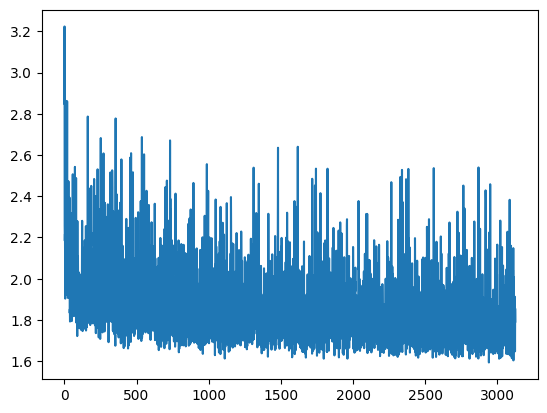

In [54]:
import matplotlib.pyplot as plt 
plt.plot(
    range(len(loss_values)), 
    loss_values
    
)
